In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage


In [29]:
df = pd.read_csv("winequality-red.csv")
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [30]:
X = df[[
    "alcohol",
    "sulphates"
]]
X

,alcohol,sulphates
0,9.4,0.56
1,9.8,0.68
2,9.8,0.65
3,9.8,0.58
4,9.4,0.56
...,...,...
1594,10.5,0.58
1595,11.2,0.76
1596,11.0,0.75
1597,10.2,0.71


In [31]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [32]:
clusters = kmeans.fit_predict(X)
df["Cluster"] = clusters

In [33]:
df["Cluster"] = clusters

for i in range(3):

    print("\n" + "="*50)
    print("CLUSTER", i + 1)
    print("="*50)

    cluster_data = df[
        df["Cluster"] == i
    ]

    print(
        cluster_data[
            [
                "alcohol",
                "sulphates"
            ]
        ]
    )

    print(
        "\nTotal Records :",
        len(cluster_data)
    )


CLUSTER 1
      alcohol  sulphates
0         9.4       0.56
1         9.8       0.68
2         9.8       0.65
3         9.8       0.58
4         9.4       0.56
...       ...        ...
1572      9.5       0.51
1583      9.8       0.62
1589      9.2       0.54
1593      9.5       0.82
1597     10.2       0.71

[842 rows x 2 columns]

Total Records : 842

CLUSTER 2
      alcohol  sulphates
45       13.1       0.56
95       12.9       0.60
131      13.0       0.63
132      13.0       0.63
142      14.0       0.79
...       ...        ...
1575     11.8       0.64
1577     11.9       0.60
1580     11.9       0.60
1582     11.9       0.50
1588     12.8       0.78

[235 rows x 2 columns]

Total Records : 235

CLUSTER 3
      alcohol  sulphates
9        10.5       0.80
11       10.5       0.80
16       10.5       0.75
31       10.6       0.57
36       10.8       0.60
...       ...        ...
1592     11.0       0.75
1594     10.5       0.58
1595     11.2       0.76
1596     11.0       0.75
15

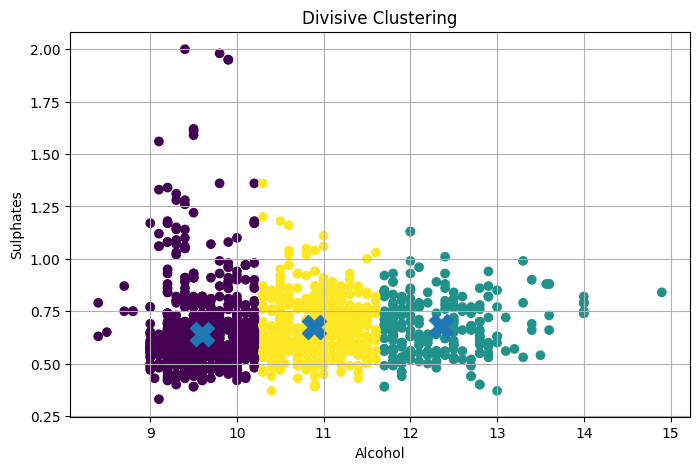

In [12]:

plt.figure(figsize=(8,5))

plt.scatter(
    X["alcohol"],
    X["sulphates"],
    c=clusters
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker="X"
)

plt.xlabel("Alcohol")
plt.ylabel("Sulphates")

plt.title("Divisive Clustering")

plt.grid(True)

plt.show()

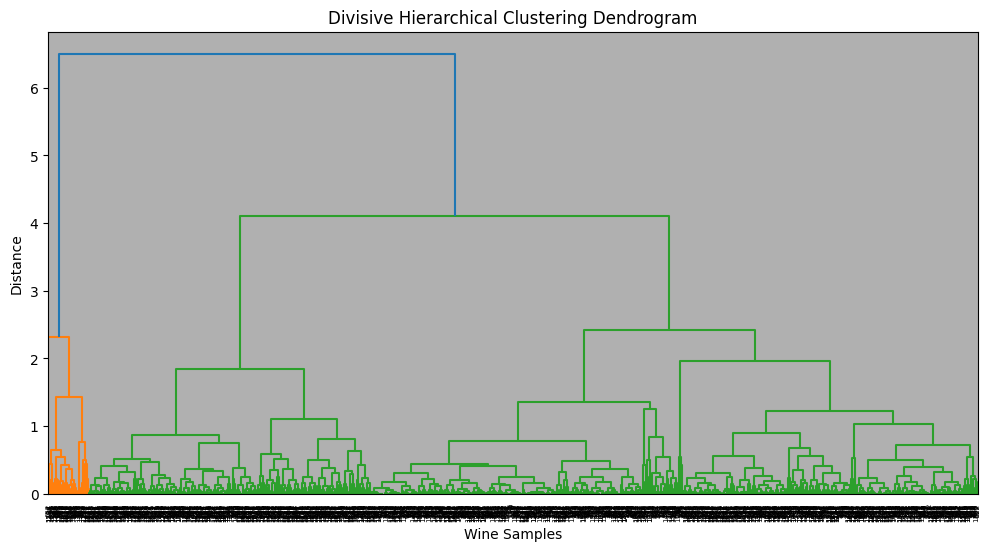

In [13]:
Z = linkage(
    X,
    method="complete"
)

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title("Divisive Hierarchical Clustering Dendrogram")
plt.xlabel("Wine Samples")
plt.ylabel("Distance")

plt.grid(True)

plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [14]:
df = pd.read_csv("Iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [15]:
print("\nMissing Values")
print(df.isnull().sum())

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)


Missing Values
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [16]:
X = df[[
    "SepalLengthCm",
    "PetalLengthCm"
]]

In [21]:
hc = AgglomerativeClustering(
    n_clusters=3
)

clusters = hc.fit_predict(X)

In [26]:
df["Cluster"] = clusters

for i in range(3):

    print("\n" + "="*50)
    print("CLUSTER", i)
    print("="*50)

    print(
        df[df["Cluster"] == i]
        [["SepalLengthCm",
          "PetalLengthCm"]]
    )


CLUSTER 0
     SepalLengthCm  PetalLengthCm
50             7.0            4.7
51             6.4            4.5
52             6.9            4.9
54             6.5            4.6
56             6.3            4.7
..             ...            ...
145            6.7            5.2
146            6.3            5.0
147            6.5            5.2
148            6.2            5.4
149            5.9            5.1

[72 rows x 2 columns]

CLUSTER 1
    SepalLengthCm  PetalLengthCm
0             5.1            1.4
1             4.9            1.4
2             4.7            1.3
3             4.6            1.5
4             5.0            1.4
5             5.4            1.7
6             4.6            1.4
7             5.0            1.5
8             4.4            1.4
9             4.9            1.5
10            5.4            1.5
11            4.8            1.6
12            4.8            1.4
13            4.3            1.1
14            5.8            1.2
15            5.7  

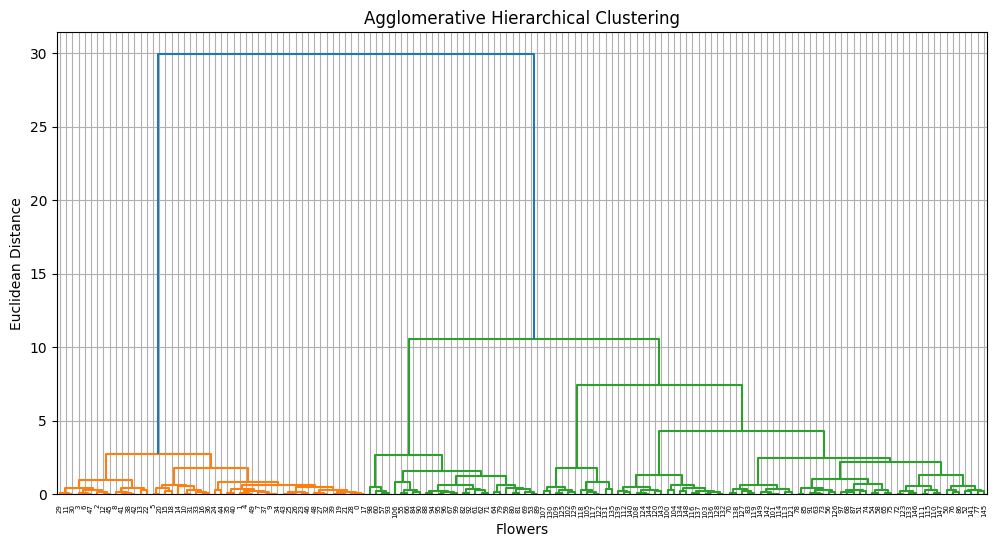

In [22]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage(
        X,
        method="ward"
    )
)

plt.title("Agglomerative Hierarchical Clustering")
plt.xlabel("Flowers")
plt.ylabel("Euclidean Distance")

plt.grid(True)

plt.show()

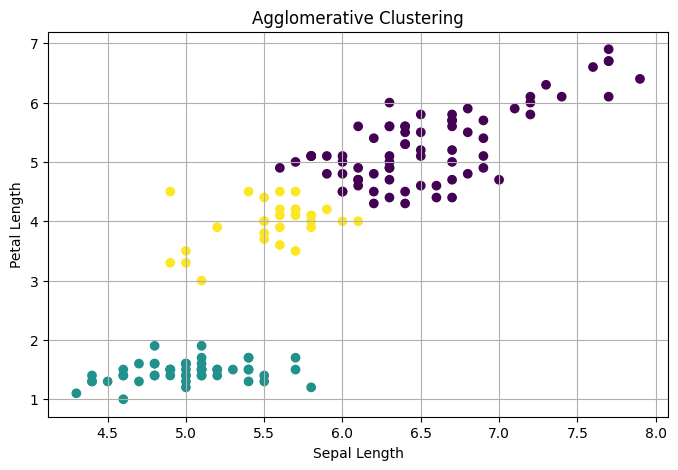

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    X["SepalLengthCm"],
    X["PetalLengthCm"],
    c=clusters
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.title("Agglomerative Clustering")

plt.grid(True)

plt.show()